# Transformers desde (casi) cero

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cam2149/icesi-nlp/blob/Entrega3/Sesion3/Entrega3.ipynb)

En este notebook implementaremos un clasificador de reseñas en español utilizando transformers. Implementaremos parte de la arquitectura del modelo pieza por pieza para ver como funciona por dentro. Sin embargo, utilizarémos las utilidades de tokenización de huggingface transformers para ayudarnos con esta tarea.

#### Referencias
- Dataset: https://huggingface.co/datasets/neonwatty/amazon_reviews_multi
- [Attention is All You Need](http://arxiv.org/abs/1706.03762)
- [Natural Language Processing with Transformers: Building Language Applications With Hugging Face](https://www.amazon.com/Natural-Language-Processing-Transformers-Applications/dp/1098103246)
- [Tutorial 5: Transformers and Multi-Head Attention](https://lightning.ai/docs/pytorch/stable/notebooks/course_UvA-DL/05-transformers-and-MH-attention.html)

##1. Configuración e Instalación

In [156]:
# Ahora vamos a crear nuestro implementación de clasificador de reseñas de Amazon en español
# Basándonos en la estructura del archivo adjunto pero adaptándolo para el dataset de Amazon

# Primero instalamos las dependencias necesarias
import sys
import subprocess

def install_packages():
    packages = [
        'torch',
        'transformers',
        'datasets',
        'tokenizers',
        'scikit-learn',
        'matplotlib',
        'seaborn',
        'optuna',
        'pandas',
        'numpy',
        'tqdm',
        'os',
        're'
    ]

    for package in packages:
        try:
            __import__(package)
            print(f"✓ {package} ya está instalado")
        except ImportError:
            print(f"Instalando {package}...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])

install_packages()



✓ torch ya está instalado
✓ transformers ya está instalado
✓ datasets ya está instalado
✓ tokenizers ya está instalado
Instalando scikit-learn...
✓ matplotlib ya está instalado
✓ seaborn ya está instalado
✓ optuna ya está instalado
✓ pandas ya está instalado
✓ numpy ya está instalado
✓ tqdm ya está instalado
✓ os ya está instalado
✓ re ya está instalado


##1.1. Importación de Librerías

In [157]:
# Importaciones principales
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import optuna
import pandas as pd
import pkg_resources
import random
import re
import seaborn as sns
import subprocess
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import warnings

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm.auto import tqdm
from transformers import AutoTokenizer
from transformers.models.gpt2.tokenization_gpt2 import bytes_to_unicode
from typing import Optional, Tuple

warnings.filterwarnings('ignore')

print("Dependencias cargadas correctamente")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
print(f"Número de GPUs: {torch.cuda.device_count() if torch.cuda.is_available() else 0}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo seleccionado: {device}")

num_heads = 8
max_len = 2048

Dependencias cargadas correctamente
PyTorch version: 2.8.0+cu126
CUDA disponible: False
Número de GPUs: 0
Dispositivo seleccionado: cpu


In [158]:
# Ignorar advertencias para evitar que el output se llene de mensajes innecesarios
warnings.filterwarnings("ignore")

# Desactivar el paralelismo en los tokenizadores de Hugging Face para evitar conflictos
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

# Ignorar advertencias (repetido para asegurar que todas las advertencias sean ignoradas)
warnings.filterwarnings('ignore')

# Función para establecer una semilla y garantizar la reproducibilidad de los resultados
def set_seed(seed):
    torch.manual_seed(seed)  # Semilla para PyTorch en la CPU
    torch.cuda.manual_seed_all(seed)  # Semilla para PyTorch en todas las GPUs
    np.random.seed(seed)  # Semilla para NumPy
    random.seed(seed)  # Semilla para el módulo random de Python
    torch.backends.cudnn.deterministic = True  # Hacer que las operaciones de cuDNN sean deterministas
    torch.backends.cudnn.benchmark = False  # Desactivar el benchmarking de cuDNN para mejorar la reproducibilidad

# Establecer la semilla en 42 para garantizar resultados reproducibles
set_seed(42)

# Crear una lista de todos los paquetes instalados en el entorno actual
installed_packages = [package.key for package in pkg_resources.working_set]

# Verificar si el código se está ejecutando en Google Colab
IN_COLAB = 'google-colab' in installed_packages


In [159]:
!test '{IN_COLAB}' = 'True' && sudo apt-get update -y
!test '{IN_COLAB}' = 'True' && sudo apt-get install python3.10 python3.10-distutils python3.10-lib2to3 -y
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.11 2
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.10 1
!test '{IN_COLAB}' = 'True' && pip install lightning datasets

Hit:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

### Cargando el dataset
Este es un dataset pequeño de reseñas de productos en español con sus respectivas categorías. El dataset está disponible en el HuggingFace Hub y puede ser fácilmente descargado con la librería.

In [160]:
# Cargar dataset
from datasets import load_dataset

def load_spanish_news_dataset_train():
    """Carga el dataset de reseñas en español"""
    return load_dataset("neonwatty/amazon_reviews_multi", "es", split='train')

# 2. Cargar el dataset_test
def load_spanish_news_dataset_test():
    """Carga el dataset de reseñas en español"""
    return load_dataset("neonwatty/amazon_reviews_multi", "es", split='test')

# 3. Cargar el dataset de validación
def load_spanish_news_dataset_valid():
    """Carga el dataset de reseñas en español"""
    return load_dataset("neonwatty/amazon_reviews_multi", "es", split='validation')

print("Cargando dataset de entrenamiento...")
dataset = load_spanish_news_dataset_train()
dataset = dataset.shuffle(seed=42)

print("Cargando dataset de test...")
dataset_test = load_spanish_news_dataset_test()
dataset_test = dataset_test.shuffle(seed=42)

print("Cargando dataset de validación...")
dataset_valid = load_spanish_news_dataset_valid()
dataset_valid = dataset_valid.shuffle(seed=42)

# Acceder a un ejemplo de la división de entrenamiento
print("Observando un ejemplo del dataset:")
example = dataset[0]
print(example)

Cargando dataset de entrenamiento...
Cargando dataset de test...
Cargando dataset de validación...
Observando un ejemplo del dataset:
{'review_title': '.', 'review_body': 'La montarlo se rompió una rueda debido a materiales débiles, pero al arreglarla funciona correctamente.', 'review_id': 'es_0614019', 'stars': 3}


In [161]:
print(dataset)

Dataset({
    features: ['review_title', 'review_body', 'review_id', 'stars'],
    num_rows: 200000
})


Para los efectos de esta tarea, nos servirán el review_title y review_body naturalmente.

A manera general, observemos que tan largos o cortos tienden a ser los textos.

In [162]:
%%time
from datasets import load_dataset

# Load all splits of the dataset
print("Cargando datasets (train, test, validation)...")
dataset_splits = {
    'train': dataset,
    'test': dataset_test,
    'validation': dataset_valid
}
print("Datasets cargados.")

def analyze_text_lengths(dataset_split, split_name):
    """Calcula y muestra las longitudes de texto para un split del dataset."""
    print(f"\nAnalizando longitudes de texto para el split: {split_name}")

    # Calculate lengths for both 'review_title' and 'review_body' and combine them
    text_lengths = [len(row['review_title']) + len(row['review_body']) for row in dataset_split]

    if text_lengths:
        print(f"Texto más corto: {min(text_lengths)}")
        print(f"Texto más largo: {max(text_lengths)}")
        print(f"Longitud promedio: {sum(text_lengths) / len(text_lengths):.2f}")
    else:
        print("No hay datos en este split para analizar.")

# Analyze each split
for split_name, dataset_split in dataset_splits.items():
    analyze_text_lengths(dataset_split, split_name)

Cargando datasets (train, test, validation)...
Datasets cargados.

Analizando longitudes de texto para el split: train
Texto más corto: 20
Texto más largo: 3160
Longitud promedio: 170.47

Analizando longitudes de texto para el split: test
Texto más corto: 22
Texto más largo: 1816
Longitud promedio: 171.08

Analizando longitudes de texto para el split: validation
Texto más corto: 22
Texto más largo: 1616
Longitud promedio: 169.40
CPU times: user 31.1 s, sys: 89.3 ms, total: 31.2 s
Wall time: 43.2 s


Estos valores son la cantidad de caractéres que tiene las secuencias. Una decisión ingenua pero útil en este momento podría ser ajustar la longitud de las secuencias que vamos a usar para el entrenamiento a unos 2000 tokens. Esto podría ser suficiente para capturar una porción significativa de los textos.

##2. Preprocesamiento de Datos
Cargamos y preprocesamos el dataset para que sea adecuado para el entrenamiento.

##2.2. Limpieza de Texto y Tokenización
Implementamos una función de limpieza para eliminar ruido del texto. Luego, usamos un tokenizador de Hugging Face para convertir el texto en secuencias de tokens.

In [163]:
# Función de limpieza de texto
def clean_text(text):
    text = re.sub(r'<[^>]+>', '', text)  # Eliminar etiquetas HTML
    text = re.sub(r'https?://\S+', '', text)  # Eliminar URLs
    text = re.sub(r'[^a-zA-ZáéíóúÁÉÍÓÚñÑüÜ\s]', '', text)  # Eliminar caracteres especiales y números
    text = text.lower()  # Convertir a minúsculas
    return text

def preprocess_text(text):
    return text.lower().replace("<br />", " ").strip()

In [164]:
%%time
# Aplicar la limpieza de texto a las reseñas
dataset = dataset.map(lambda example: {'review_body': preprocess_text(example['review_body'])})
dataset_valid = dataset_valid.map(lambda example: {'review_body': preprocess_text(example['review_body'])})
dataset_test = dataset_test.map(lambda example: {'review_body': preprocess_text(example['review_body'])})

CPU times: user 27.9 ms, sys: 9.97 ms, total: 37.9 ms
Wall time: 62.6 ms


In [165]:
%%time
# Aplicar la limpieza de texto a las reseñas
dataset = dataset.map(lambda example: {'review_body': clean_text(example['review_body'])})
dataset_valid = dataset_valid.map(lambda example: {'review_body': clean_text(example['review_body'])})
dataset_test = dataset_test.map(lambda example: {'review_body': clean_text(example['review_body'])})

CPU times: user 25.7 ms, sys: 6.02 ms, total: 31.7 ms
Wall time: 32.1 ms


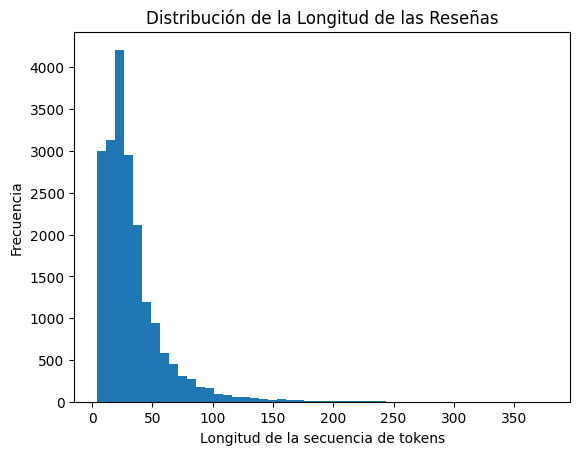

CPU times: user 8.55 s, sys: 59.8 ms, total: 8.61 s
Wall time: 8.73 s


In [166]:
%%time
from datasets import load_dataset

# Select a subset of the dataset for analysis by shuffling and taking the first sample_size elements
sample_size = 20000
# Shuffle the dataset and select the first 'sample_size' elements
dataset_shuffled = dataset.shuffle(seed=42)
df_sample = dataset_shuffled.select(range(sample_size))

# Analizar la distribución de la longitud de las reseñas para determinar max_len
# Ensure 'review_body' is accessible as a list or similar for the list comprehension
review_lengths = [len(tokenizer.encode(review, add_special_tokens=True)) for review in df_sample['review_body']]
plt.hist(review_lengths, bins=50)
plt.title('Distribución de la Longitud de las Reseñas')
plt.xlabel('Longitud de la secuencia de tokens')
plt.ylabel('Frecuencia')
plt.show()


## Definiendo el Tokenizer

Ahora, vamos a definir el tokenizer para nuestra tarea. Para ahorrarnos tiempo, vamos a entrenar uno basado en dccuchile/bert-base-spanish-wwm-cased, ajustado a nuestro dataset. Para ello, debemos seleccionar una muestra representativa de nuestro dataset, como no es muy grande, casi que podemos usarlo todo. Luego, debemos definir el tamaño del vocabulario, es decir, cuantos tokens únicos queremos soportar en nuestro tokenizador. Para que un modelo de lenguaje funcione moderadamente bien para una tarea de clasificación, considerando el tamaño de nuestro corpus, deberíamos definir unos 50 mil tokens.

In [167]:
%%time
# Inicializar el tokenizador
model_name = "dccuchile/bert-base-spanish-wwm-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Mapeo de bytes a caracteres Unicode...")
# Mapeo de bytes a caracteres Unicode: crea un diccionario que asigna cada byte a un carácter Unicode
byte_to_unicode_map = bytes_to_unicode()

# Mapeo inverso: crea un diccionario que asigna cada carácter Unicode a su byte correspondiente
unicode_to_byte_map = dict((v, k) for k, v in byte_to_unicode_map.items())

# Base del vocabulario: crea una lista con los caracteres Unicode que forman la base del vocabulario
base_vocab = list(unicode_to_byte_map.keys())
print("Crear iteradores para los conjuntos de datos: dataset, dataset_valid y dataset_test...")
# Crear iteradores para los conjuntos de datos: dataset, dataset_valid y dataset_test
iter_dataset = iter(dataset)
iter_dataset_valid = iter(dataset_valid)
iter_dataset_test = iter(dataset_test)

# Función para generar lotes (batches) de datos desde un iterador
def batch_iterator(dataset_iterator, batch_size: int = 10):
    while True:
        batch = []
        try:
            # Agregar elementos al lote hasta alcanzar el tamaño especificado
            for _ in range(batch_size):
                batch.append(next(dataset_iterator)['review_body'])
            yield batch  # Devolver el lote completo
        except StopIteration:
            # Si se alcanza el final del iterador, devolver el último lote y salir
            if batch:
                yield batch
            break

# Entrenar un nuevo tokenizador usando el iterador de lotes para el conjunto de datos principal
# vocab_size: tamaño del vocabulario (50,000 en este caso)
# initial_alphabet: caracteres base del vocabulario
print(" Entrenar un nuevo tokenizador usando el iterador de lotes para el conjunto de datos principal")
spanish_news_tokenizer = tokenizer.train_new_from_iterator(batch_iterator(iter_dataset), vocab_size=50000, initial_alphabet=base_vocab)

# Entrenar un nuevo tokenizador para el conjunto de datos de validación
# vocab_size: tamaño del vocabulario basado en el tamaño del conjunto de validación
print(" Entrenar un nuevo tokenizador para el conjunto de datos de validación")
spanish_news_tokenizer_val = tokenizer.train_new_from_iterator(batch_iterator(iter_dataset_valid), vocab_size=len(dataset_valid), initial_alphabet=base_vocab)

# Entrenar un nuevo tokenizador para el conjunto de datos de prueba
# vocab_size: tamaño del vocabulario basado en el tamaño del conjunto de prueba
print(" Entrenar un nuevo tokenizador para el conjunto de datos de prueba")
spanish_news_tokenizer_test = tokenizer.train_new_from_iterator(batch_iterator(iter_dataset_test), vocab_size=len(dataset_test), initial_alphabet=base_vocab)


Mapeo de bytes a caracteres Unicode...
Crear iteradores para los conjuntos de datos: dataset, dataset_valid y dataset_test...
 Entrenar un nuevo tokenizador usando el iterador de lotes para el conjunto de datos principal
 Entrenar un nuevo tokenizador para el conjunto de datos de validación
 Entrenar un nuevo tokenizador para el conjunto de datos de prueba
CPU times: user 39.6 s, sys: 220 ms, total: 39.8 s
Wall time: 52.9 s


In [168]:
tokens = sorted(spanish_news_tokenizer.vocab.items(), key=lambda x: x[1], reverse=False)
print(f"Vocabulario: {spanish_news_tokenizer.vocab_size} tokens")
print("Primeros 15 tokens:")
print([f"{spanish_news_tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[:15]])
print("15 tokens de en medio:")
print([f"{spanish_news_tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[1000:1015]])
print("Últimos 15 tokens:")
print([f"{spanish_news_tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[-15:]])

Vocabulario: 50000 tokens
Primeros 15 tokens:
['[MASK]', '[PAD]', '[UNK]', '[CLS]', '[SEP]', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*']
15 tokens de en medio:
['tras', 'sea', '##jas', 'can', '##tras', '##ren', '##dí', 'vis', 'espa', 'poder', '##ban', 'diseño', 'pod', 'tienes', 'mí']
Últimos 15 tokens:
['pómez', 'pómulos', 'polaca', 'scaner', 'scanear', 'wmv', 'worten', 'wilson', 'williams', '##stone', '##utsche', 'escarmentado', 'esceptica', 'untuoso', 'untuosidad']


Vemos que los primeros tokens corresponden a caracteres especiales y puntiación. Luego en el medio tenemos una combinación entre palabras completas y cortadas, el tokenizador se encarga de encontrar las frecuencias más comunes y asi partir las palabras por aquellas partes que tienden a repetirse mas. Esto es muy útil para trabajar con modelos de lenguaje ya que el modelo se vuelve robusto a diferentes ramificaciones de palabras e incluso a errores de tipografía. Finalmente, al final, vemos que tenemos más palabras cortadas y palabras muy especiales. Algo importante aquí es que podamos ver que los tokens tienen sentido con respecto a nuestro corpus.

Ahora veamos como convierte el tokenizador una oración muy sencilla:

In [169]:
spanish_news_tokenizer.pad_token = '[PAD]'
spanish_news_tokenizer("hola mundo!", max_length=8, truncation=True, padding='max_length')

{'input_ids': [3, 2202, 2387, 5, 4, 1, 1, 1], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 0, 0, 0]}

La salida del tokenizador para la frase "hola mundo!" es un diccionario que contiene la representación numérica del texto, preparada para ser utilizada como entrada en un modelo Transformer:

- **`input_ids`**: Esta es una lista de enteros que representan los IDs de los tokens para la secuencia de entrada. Cada entero corresponde a un token específico en el vocabulario del tokenizador. También se incluyen tokens especiales como `[CLS]` (para clasificación), `[SEP]` (separador) y `[PAD]` (padding), cada uno con su propio ID.
  - En tu ejemplo `[3, 2202, 2387, 5, 4, 1, 1, 1]`:
    - `3` es el ID para `[CLS]`.
    - `2202` es el ID para el token "hola".
    - `2387` es el ID para el token "mundo".
    - `5` es el ID para el token "!".
    - `4` es el ID para `[SEP]`.
    - `1` es el ID para `[PAD]`. La secuencia se rellena hasta la `max_length` (8 en este caso).

- **`token_type_ids`**: Esta es una lista de enteros que identifica a qué secuencia pertenece un token cuando se concatenan múltiples secuencias (por ejemplo, para tareas como respuesta a preguntas donde tienes una pregunta y un pasaje). En tu caso, como solo hay una secuencia, todos los tokens pertenecen al mismo tipo, generalmente representado por 0.

- **`attention_mask`**: Esta es una lista de enteros (1 o 0) que indica a qué tokens debe prestar atención el modelo. Los tokens con valor 1 son tokens reales que el modelo debe procesar, mientras que los tokens con valor 0 suelen ser tokens de relleno (padding) que el modelo debe ignorar.
  - En tu ejemplo `[1, 1, 1, 1, 1, 0, 0, 0]`: Los primeros 5 tokens (correspondientes a `[CLS]`, "hola", "mundo", "!", `[SEP]`) tienen un valor de 1, lo que significa que se debe prestar atención a ellos. Los 3 tokens restantes tienen un valor de 0, indicando que son relleno y deben ser ignorados.

In [170]:
spanish_news_tokenizer("hola mundo!", max_length=8, truncation=True, padding='max_length').tokens()

['[CLS]', 'hola', 'mundo', '!', '[SEP]', '[PAD]', '[PAD]', '[PAD]']

Claramente vemos los 3 tokens como cadenas independientes.

In [172]:
import torch
import numpy as np
from typing import Tuple, Dict
from torch.utils.data import Dataset

# Dataset personalizado
class SpanishReviewsDataset(Dataset):
    # El constructor inicializa el dataset personalizado.
    # Recibe un tokenizador (función), el dataset original de Hugging Face y la longitud máxima de secuencia.
    def __init__(self, tokenizer, dataset, seq_length: int = 128):
        # Almacena el tokenizador, el dataset original y la longitud máxima.
        self.tokenizer = tokenizer
        self.dataset = dataset
        self.seq_length = seq_length
        # Definimos estos dos mapas para facilitarnos la tarea
        # de traducir de nombres de categoría a ids de categoría.
        # id_2_class_map: Mapea IDs numéricos (0, 1, 2, 3, 4) a las clases originales de estrellas (1, 2, 3, 4, 5).
        self.id_2_class_map = dict(enumerate(np.unique(dataset[:]['stars'])))
        # class_2_id_map: Mapea las clases originales de estrellas (1, 2, 3, 4, 5) a IDs numéricos (0, 1, 2, 3, 4).
        self.class_2_id_map = {v: k for k, v in self.id_2_class_map.items()}
        # Almacena el número total de clases (5 en este caso).
        self.num_classes = len(self.id_2_class_map)
        # Get the UNK token ID from the tokenizer
        self.unk_token_id = self.tokenizer.unk_token_id


    # Este método es fundamental para PyTorch Datasets y define cómo obtener un elemento individual.
    # Recibe un índice y devuelve un diccionario con los datos de entrada y la etiqueta.
    def __getitem__(self, index) -> Dict[str, torch.Tensor]:
        # Obtiene el texto de la reseña y la calificación de estrellas del dataset original por índice.
        text, y = self.dataset[index]['review_body'], self.dataset[index]['stars']
        # Convierte la calificación de estrellas a su ID numérico usando el mapa.
        y = self.class_2_id_map[y]
        # Tokeniza el texto de la reseña, limita la longitud y obtiene the encoding object
        encoding = self.tokenizer(text, max_length=self.seq_length, padding='max_length', truncation=True)

        # Convert encoding components to NumPy arrays before creating tensors
        input_ids_np = np.array(encoding['input_ids'])
        attention_mask_np = np.array(encoding['attention_mask'])

        # Create tensors
        input_ids_tensor = torch.tensor(input_ids_np, dtype=torch.long)
        attention_mask_tensor = torch.tensor(attention_mask_np, dtype=torch.long)
        y_tensor = torch.tensor(y, dtype=torch.long)

        # Check for and replace out-of-range token IDs with UNK token ID directly on the tensor
        vocab_size = self.tokenizer.vocab_size
        input_ids_tensor[input_ids_tensor >= vocab_size] = self.unk_token_id


        data = {
            'input_ids': input_ids_tensor,
            'attention_mask': attention_mask_tensor,
            'y': y_tensor
        }

        # Devuelve el diccionario con los datos preparados.
        return data

    # Este método es requerido para PyTorch Datasets y devuelve el número total de elementos en el dataset.
    def __len__(self):
        # Retorna la longitud del dataset original.
        return len(self.dataset)

In [173]:

# Assuming dataset_splits contains the loaded train, test, and validation datasets
if 'dataset_splits' in globals():
    for split_name, dataset_split in dataset_splits.items():
        print(f"\nCreando y verificando Dataset personalizado para el split: {split_name}")
        try:
            spanish_news_dataset = SpanishReviewsDataset(spanish_news_tokenizer, dataset_split, seq_length=max_len)
            assert len(spanish_news_dataset) == len(dataset_split)
            print(f"✓ Dataset personalizado '{split_name}' creado con éxito y longitud verificada.")
        except AssertionError:
            print(f"Dataset personalizado '{split_name}' creado, la longitud verificada no es correcta.")
        except Exception as e:
            print(f"Ocurrió un error al crear el dataset personalizado '{split_name}': {e}")
else:
    print("Error: 'dataset_splits' no encontrado. Por favor, asegúrate de que los datasets de train, test y validation estén cargados.")


Creando y verificando Dataset personalizado para el split: train
✓ Dataset personalizado 'train' creado con éxito y longitud verificada.

Creando y verificando Dataset personalizado para el split: test
✓ Dataset personalizado 'test' creado con éxito y longitud verificada.

Creando y verificando Dataset personalizado para el split: validation
✓ Dataset personalizado 'validation' creado con éxito y longitud verificada.


In [175]:
%%time
# Calcular la longitud de cada reseña en el dataset después de tokenizarla
# Para cada reseña en la columna 'review_body' del dataset:
# 1. Se tokeniza la reseña usando el tokenizador predefinido.
# 2. Se agregan tokens especiales (como [CLS] y [SEP] en BERT).
# 3. Se calcula la longitud de la secuencia tokenizada.
# El resultado es una lista llamada 'review_lengths' que contiene las longitudes de todas las reseñas.
review_lengths = [len(tokenizer.encode(review, add_special_tokens=True, truncation=True, max_length=512)) for review in dataset['review_body']]

# Determinar la longitud máxima de la secuencia (max_len) usando el percentil 95
# Esto es útil para evitar secuencias demasiado largas, que podrían ser atípicas o ruidosas.
# - np.percentile(review_lengths, 95): Calcula el valor del percentil 95 de las longitudes.
# - int(...): Convierte el resultado a un número entero.
# Alternativamente, se podría usar un valor fijo como max_len = 512 (longitud máxima del modelo).
max_len = min(int(np.percentile(review_lengths, 95)), 512)  # Asegurar que max_len no exceda 512

# Imprimir la longitud máxima de la secuencia (percentil 95)
print(f"Longitud máxima de la secuencia (percentil 95): {max_len}")


Longitud máxima de la secuencia (percentil 95): 81
CPU times: user 1min 19s, sys: 77.8 ms, total: 1min 19s
Wall time: 1min 20s


In [176]:
%%time

# Assuming dataset_splits contains the loaded train, test, and validation datasets
spanish_news_datasets_splits = {} # Dictionary to store custom datasets

if 'dataset_splits' in globals():
    for split_name, dataset_split in tqdm(dataset_splits.items(), desc=f'Procesando: {split_name}'):
        print(f"\nCreando y verificando Dataset personalizado para el split: {split_name}")
        try:
            spanish_news_dataset = SpanishReviewsDataset(spanish_news_tokenizer, dataset_split, seq_length=max_len)
            spanish_news_datasets_splits[split_name] = spanish_news_dataset # Store in dictionary
            print(f"Dataset '{split_name}' insertado. Tamaño: {len(spanish_news_datasets_splits[split_name])}") # Display size
            assert len(spanish_news_dataset) == len(dataset_split)
            print(f"✓ Dataset personalizado '{split_name}' creado con éxito y longitud verificada.")
        except AssertionError:
            print(f"Dataset personalizado '{split_name}' creado, la longitud verificada no es correcta.")
        except Exception as e:
            print(f"Ocurrió un error al crear el dataset personalizado '{split_name}': {e}")
else:
    print("Error: 'dataset_splits' no encontrado. Por favor, asegúrate de que los datasets de train, test y validation estén cargados.")

Procesando: validation:   0%|          | 0/3 [00:00<?, ?it/s]


Creando y verificando Dataset personalizado para el split: train
Dataset 'train' insertado. Tamaño: 200000
✓ Dataset personalizado 'train' creado con éxito y longitud verificada.

Creando y verificando Dataset personalizado para el split: test
Dataset 'test' insertado. Tamaño: 5000
✓ Dataset personalizado 'test' creado con éxito y longitud verificada.

Creando y verificando Dataset personalizado para el split: validation
Dataset 'validation' insertado. Tamaño: 5000
✓ Dataset personalizado 'validation' creado con éxito y longitud verificada.
CPU times: user 6.86 s, sys: 248 ms, total: 7.11 s
Wall time: 9.74 s


In [177]:
print('Train:',len(spanish_news_datasets_splits["train"]))
print('validation:',len(spanish_news_datasets_splits["validation"]))
print('test:',len(spanish_news_datasets_splits["test"]))

Train: 200000
validation: 5000
test: 5000


Y luego, procedemos a crear los dataloaders.

In [178]:
from torch.utils.data import random_split
from torch.utils.data import DataLoader

batch_size = 4 if not IN_COLAB else 12

train_loader = DataLoader(spanish_news_datasets_splits["train"], batch_size=batch_size, shuffle=True, num_workers=2) # Set num_workers to 0
val_loader = DataLoader(spanish_news_datasets_splits["validation"], batch_size=batch_size, shuffle=False, num_workers=2) # Set num_workers to 0
test_loader = DataLoader(spanish_news_datasets_splits["test"], batch_size=batch_size, shuffle=False, num_workers=2) # Set num_workers to 0

In [179]:
import numpy as np
import torch.nn as nn
from enum import Enum
from typing import Optional
import torch # Import torch here if not already imported

class PosEncodingType(Enum):
    SINUSOID = 1
    LEARNABLE = 2


class SinusoidPE(nn.Module):
    def __init__(self, max_len: int, d_model: int):
        super(SinusoidPE, self).__init__()
        # Definimos un vector columna con las posiciones de la secuencia de entrada (pos)
        pos = torch.arange(max_len).unsqueeze(1)
        # Definimos un vector de fila con las dimensiones del embedding (i)
        i = torch.arange(d_model).unsqueeze(0)

        # Calculamos el denominador segun la formula
        div_term = 1 / torch.pow(10000, (2 * (i // 2)) / torch.tensor(d_model, dtype=torch.float32))
        # Aplicamos el denominador a las posiciones
        angle_rads = pos * div_term

        # Inicializamos la matriz de positional encodings
        pos_encoding = torch.zeros(max_len, d_model)
        # Calculamos los embeddings para los numeros pares con seno: PE(pos, 2i)
        pos_encoding[:, 0::2] = torch.sin(angle_rads[:, 0::2])
        # Calculamos los embdeddings para los numeros inpares con coseno: PE(pos, 2i+1)
        pos_encoding[:, 1::2] = torch.cos(angle_rads[:, 1::2])

        # Registramos la variable como atributo de clase
        self.register_buffer("pos_encoding", pos_encoding.unsqueeze(0), persistent=False)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pos_encoding[:, :x.size(1), :]


class LearnablePE(nn.Module):

    def __init__(self, vocab_size: int, d_model: int, max_len: int = float('-inf')):
        super(LearnablePE, self).__init__()
        self.max_len = max_len
        # Embedding dimension should be d_model, number of embeddings is max_len
        self.embedding = nn.Embedding(max_len, d_model)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Create positions tensor based on sequence length of x
        positions = torch.arange(0, x.size(1), device=x.device)
        pos_emb = self.embedding(positions)
        # Expand pos_emb for broadcasting: (sequence_length, d_model) -> (1, sequence_length, d_model)
        pos_emb = pos_emb.unsqueeze(0)
        return x + pos_emb



class TokenAndPosEmbedding(nn.Module):

    def __init__(self, max_len: int, embed_dim: int, vocab_size: int, pos_encoding_type: PosEncodingType = PosEncodingType.SINUSOID):
        super(TokenAndPosEmbedding, self).__init__()
        self.token_emb = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)
        if pos_encoding_type == PosEncodingType.SINUSOID:
            self.pos_emb = SinusoidPE(max_len, embed_dim)
        else:
            # Pass max_len to LearnablePE
            self.pos_emb = LearnablePE(vocab_size, embed_dim, max_len=max_len)


    def forward(self, x):
        token_emb = self.token_emb(x)
        return self.pos_emb(token_emb)

In [180]:
emb_dim = 128 if not IN_COLAB else 256
tpe = TokenAndPosEmbedding(max_len, emb_dim, spanish_news_tokenizer.vocab_size)
pos_encoding = tpe.pos_emb.pos_encoding.squeeze(0).numpy()

A manera exploratoria, podemos observar gráficamente en que consisten estos vectores. En el siguiente gráfico podemos observar como los valores tienden a oscilar para diferentes posiciones en la dimensionalidad del embedding. Los valores individuales no tienen una interpretación directa, pero lo que vale la pena resaltar es que se observa una "transición" a medida que nos desplazamos por las dimensiones del embedding y sus respectivas posiciones, no es solo ruido.

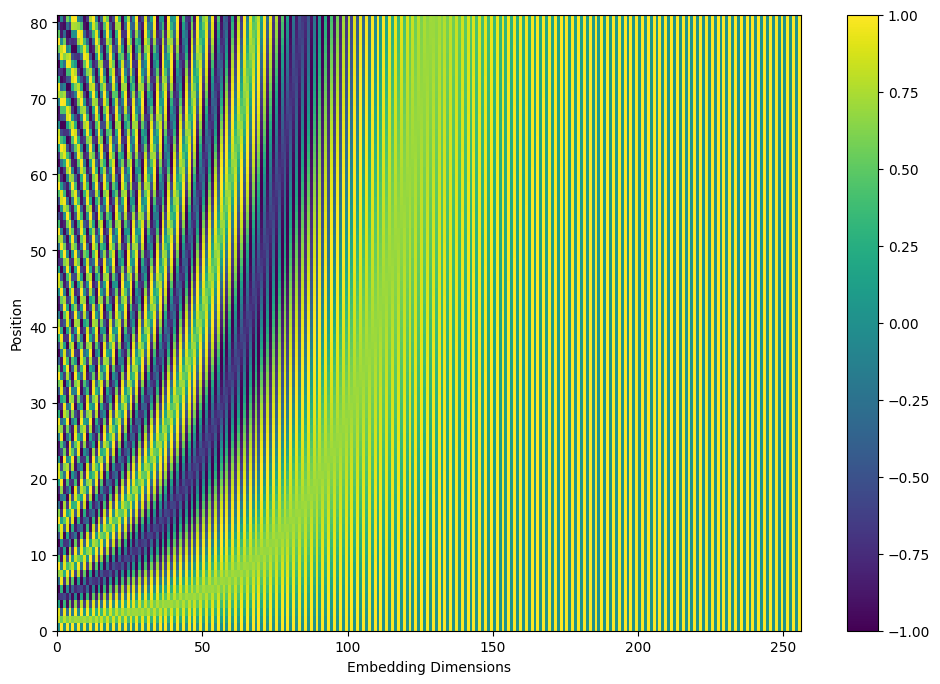

In [181]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.pcolormesh(pos_encoding, cmap='viridis')
plt.xlabel('Embedding Dimensions')
plt.xlim((0, emb_dim))
plt.ylabel('Position')
plt.colorbar()
plt.show()

In [182]:
text = "hola mundo!"
tokens = spanish_news_tokenizer(text, max_length=max_len, truncation=True, padding='max_length')
x = torch.tensor(tokens['input_ids']).unsqueeze(0)
mask = torch.tensor(tokens['input_ids']).unsqueeze(0)
embedding = tpe(x)
embedding.shape

torch.Size([1, 81, 256])

##Módulo de Atención y Bloque del Transformer

Implementamos la atención multi-cabeza y el bloque básico del Transformer Encoder.

In [187]:
#Implementación de Multi-Head Attention
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads: int = 8):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model debe ser divisible por num_heads"

        self.d_k = d_model // num_heads # Dimensión de la clave, consulta y valor por cabeza
        self.num_heads = num_heads # Número de cabezas de atención
        self.d_model = d_model  # Dimensión del modelo

        self.wq = nn.Linear(d_model, d_model) # Proyección lineal para las consultas
        self.wk = nn.Linear(d_model, d_model) # Proyección lineal para los valores
        self.wv = nn.Linear(d_model, d_model) # Proyección lineal para las claves

        self.fc = nn.Linear(d_model, d_model)  # Proyección final

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        # Calcula los scores de atención
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # Aplica la máscara (para evitar atender a tokens futuros o padding)
        if mask is not None:
            # Expand the mask to be broadcastable with scores
            # Mask shape: (batch_size, sequence_length) -> (batch_size, 1, 1, sequence_length)
            mask = mask.unsqueeze(1).unsqueeze(2)
            scores = scores.masked_fill(mask == 0, -1e9)

        # Aplica softmax para obtener las pesos de atención
        attention_weights = F.softmax(scores, dim=-1)

        # Multiplica los pesos por los valores para obtener la salida
        output = torch.matmul(attention_weights, V)

        return output, attention_weights

    def forward(self, Q, K, V, mask=None):
        batch_size = Q.size(0)

        # Proyecta Q, K, V linealmente y divide en múltiples cabezas
        Q = self.wq(Q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.wk(K).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.wv(V).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # Calcula la atención para cada cabeza
        attn_output, attention_weights = self.scaled_dot_product_attention(Q, K, V, mask)

        # Concatena las salidas de las cabezas y aplica la capa lineal final
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        output = self.fc(attn_output)

        return output, attention_weights

In [188]:
mha = MultiHeadAttention(emb_dim, num_heads=8)
mha(embedding, embedding, embedding, mask)[0].shape

torch.Size([1, 81, 256])

## Definición del bloque transformers
Finalmente, definimos el bloque de transformers. Recordemos que como esta es una tarea de clasificación, solamente necesitamos el encoder, por lo que esto es silamente la primera parte del diseño de arquitecura de red.

En esta capa, simplemente ponemos una capa densa adicional junto con las normalizaciones a nivel de capa.

In [189]:
# 3. Implementación de un bloque Transformer
class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads: int = 8, d_ff: int = 512, dropout=0.1):
        super(TransformerBlock, self).__init__()

        self.attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.feed_forward = nn.Sequential(  # Red neuronal feed-forward
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        """
        Paso forward del bloque del encoder.
        Args:
            x: Tensor de entrada (batch, secuencia, d_model)
            mask: Máscara de atención
        """
        # Bloque de atención con conexión residual y normalización
        attn_output, _ = self.attention(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))

        # Feed-forward con conexión residual
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x


In [190]:
tb = TransformerBlock(emb_dim, num_heads=8, d_ff=512)
tb(embedding, mask).shape

torch.Size([1, 81, 256])

In [191]:
num_heads = 8
vocab_size = spanish_news_tokenizer.vocab_size

token_embeddings = TokenAndPosEmbedding(max_len, emb_dim, vocab_size)
transformer = TransformerBlock(emb_dim, num_heads)
ff = nn.Sequential(
    nn.Flatten(),
    nn.Linear(max_len * emb_dim, spanish_news_dataset.num_classes)
)

In [192]:
it = iter(train_loader)
batch = next(it)
x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']

embeddings = token_embeddings(x)
assert embeddings.shape == (train_loader.batch_size, max_len, emb_dim)

attention = transformer(embeddings, mask)
attention.shape

torch.Size([12, 81, 256])

In [193]:
pred = ff(attention)
pred.shape

torch.Size([12, 5])

##Visualización del Positional Encoding

In [194]:
# Convertir categorías a números
unique_categories = list(set(categories))
category_to_id = {cat: idx for idx, cat in enumerate(unique_categories)}
labels = [category_to_id[cat] for cat in categories]

print(f"Categorías encontradas: {unique_categories}")
print(f"Número de clases: {len(unique_categories)}")


Categorías encontradas: [1, 2, 3, 4, 5]
Número de clases: 5


##Definición del clasificador

Finalmente, definimos el modelo en si. Este modelo constará de 3 capas:

La tokenización, tal como la definimos anteriormente.
El transformer, que acabamos de decinir.
Una capa densa adicional que servirá como clasificador de aquello que nos entregue la capa del transformer.
Como este es un LightningModule, aquí definiremos el resto de funciones utilitarias para el entrenamiento de la tarea.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from pytorch_lightning import LightningModule, Trainer
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from torchmetrics import Accuracy


class SpanishNewsClassifier(LightningModule):

    def __init__(self, max_len: int, vocab_size: int, num_classes: int, emb_dim: int, num_heads: int = 8):
        super(SpanishNewsClassifier, self).__init__()
        self.num_classes = num_classes

        self.token_embeddings = TokenAndPosEmbedding(max_len, emb_dim, vocab_size)
        self.transformer = TransformerBlock(emb_dim, num_heads)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(max_len * emb_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes),
            nn.LogSoftmax(dim=1)
        )

        self.train_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.test_acc = Accuracy(task='multiclass', num_classes=num_classes)


    def forward(self, x, mask=None):
        embeddings = self.token_embeddings(x)
        attention = self.transformer(embeddings, mask)
        return self.classifier(attention)


    def training_step(self, batch):
        x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']
        y_hat = self(x, mask)
        loss = F.cross_entropy(y_hat, y)
        self.train_acc(y_hat, y)
        self.log('train-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('train-acc', self.train_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch):
        x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']
        y_hat = self(x, mask)
        loss = F.cross_entropy(y_hat, y)
        self.val_acc(y_hat, y)
        self.log('val-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('val-acc', self.val_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def test_step(self, batch):
        x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']
        y_hat = self(x, mask)
        self.test_acc(y_hat, y)
        self.log('test-acc', self.test_acc, prog_bar=True, on_step=False, on_epoch=True)


    def predict_step(self, batch):
        x, mask = batch['input_ids'], batch['attention_mask']
        return self(x, mask)


    def configure_optimizers(self):
        optimizer =  torch.optim.AdamW(self.parameters(), lr=2e-5, weight_decay=1e-5)
        return optimizer


model = SpanishNewsClassifier(max_len=spanish_news_dataset.seq_length, vocab_size=spanish_news_tokenizer.vocab_size, num_classes=spanish_news_dataset.num_classes, emb_dim=emb_dim)

tb_logger = TensorBoardLogger('tb_logs', name='TransformersClassifier')
callbacks=[EarlyStopping(monitor='train-loss', patience=3, mode='min')]
trainer = Trainer(max_epochs=10, devices=1, logger=tb_logger, callbacks=callbacks, precision="16-mixed")

trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

INFO:pytorch_lightning.utilities.rank_zero:Using bfloat16 Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | token_embeddings | TokenAndPosEmbedding | 12.8 M | train
1 | transformer      | TransformerBlock     | 527 K  | train
2 | classifier       | Sequential           | 10.7 M | train
3 | train_acc        | MulticlassAccuracy   | 0      | train
4 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

In [ ]:
%load_ext tensorboard

In [ ]:
%tensorboard --logdir tb_logs/


Y como es de esperarse, realizaremos la validación contra el conjunto de prueba.



In [ ]:
model.eval()
trainer.test(model, test_loader)

#Haciendo predicciones
Finalmente, vamos a hacer uso del modelo y ver que tan bueno es para la clasificación de reseñas.



In [ ]:
predictions = trainer.predict(model, test_loader)
predictions = torch.cat(predictions, dim=0)
predictions = torch.argmax(predictions, dim=-1)
predictions = [spanish_news_dataset.id_2_class_map[pred] for pred in predictions.numpy()]

In [ ]:
import pandas as pd

test_indices = test_dataset.indices
df = pd.DataFrame(data={
    "texto": dataset[test_indices]['review_body'],
    "tokens": [spanish_news_tokenizer(v)['input_ids'] for v in dataset[test_indices]['review_body']],
    "stars": dataset[test_indices]['stars'],
    'predicción': predictions
}, index=test_indices)

df['tokens_string'] = df.tokens.apply(lambda t: spanish_news_tokenizer.convert_ids_to_tokens(t))
df = df[["texto", "tokens", "tokens_string", "stars", "predicción"]]
df.style.set_table_styles(
    [
        {'selector': 'td', 'props': [('word-wrap', 'break-word')]}
    ]
)
df.head(15)

In [ ]:
errors = df[df['stars'] != df['predicción']]
errors.head(15)